# 六个涨跌停情绪因子：多指数择时与 IC 分析

研究流程：构造共用因子信号 → 逐指数择时回测 → 逐指数 IC 比较。


In [17]:
import importlib
import sys
import warnings
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "my_utils").is_dir():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError("未找到项目根目录：上级目录中缺少 my_utils/")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from my_utils.fun import read_day_data
from my_utils.rqdata import RqData
from 因子回测.alpha import add_future_return
# Notebook 内核会缓存已导入模块；主动刷新，避免代码更新后仍使用旧函数集合。
from 因子回测.涨跌停情绪因子 import timing_engine as _timing_engine
importlib.reload(_timing_engine)
from 因子回测.涨跌停情绪因子.timing_engine import (
    analyze_ic, analyze_rolling_ic,
    build_daily_sentiment_factors, compute_threshold,
    prepare_stock_daily,
    run_time_backtest, summarize_timing,
)

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False
warnings.filterwarnings("ignore", message="Glyph .* missing from current font")

START_DATE = date(2018, 1, 2)
END_DATE = date(2026, 7, 27)
DATA_SOURCE = "rq_stock_all_data"
WINDOW = 5
HORIZONS = (1, 3, 5, 10)
ROLLING_IC_WINDOWS = (50, 100)
ROLLING_IC_MIN_VALID_RATIO = 0.95
IC_NEUTRAL_BAND = 0.02
THRESHOLD_QUANTILE = 0.60
MIN_HISTORY = 252
PRICE_TOLERANCE = 1e-6
FACTOR_LABELS = {
    "limit_up_ratio": "涨停占比", "limit_down_ratio": "跌停占比",
    #"net_limit_ratio": "净涨停占比（涨跌停强度）",
    #"limit_up_down_ratio": "涨跌停比值",
    "limit_up_next_ret": "涨停次日收益", "limit_down_next_ret": "跌停次日收益",
}
FACTOR_DIRECTIONS = {factor: 1 for factor in FACTOR_LABELS}
FACTOR_COLUMNS = list(FACTOR_LABELS)

# 指数数据在 Notebook 外层通过米筐获取；回测函数只接收整理好的收益列。
BENCHMARK_CODES = {
    "hs300": "000300.XSHG",
    "zz500": "000905.XSHG",
    "zz1000": "000852.XSHG",
    "zz2000": "000906.XSHG",
    "cyb": "399006.XSHE",
    "kc50": "000688.XSHG",
}
BENCHMARK_LABELS = {
    "sz50": "上证50", "hs300": "沪深300", "zz500": "中证500","zz1000": "中证1000", "zz2000": "中证2000",
    "cyb": "创业板指", "kc50": "科创50",
}


def prepare_rq_benchmark_returns(rq_returns, benchmark_codes):
    """把米筐多指数 MultiIndex 收益表拆成单指数标准 Pandas 表。

    NaN / inf 处理策略：
    - 发现无效行（NaN/inf）时打印详细警告并跳过，不直接抛异常；
    - 跳过后若某指数一行不剩，仍抛出 ValueError 提示数据缺失；
    - 跳过后若剩余行中存在重复日期，也抛出 ValueError。
    """
    if not isinstance(rq_returns, pd.DataFrame):
        raise TypeError("rq_returns 必须是 pandas.DataFrame")
    if not isinstance(rq_returns.index, pd.MultiIndex):
        raise ValueError("rq_returns 必须使用 order_book_id + date 的 MultiIndex")
    if not {"order_book_id", "date"}.issubset(rq_returns.index.names):
        raise ValueError("米筐收益索引必须包含 order_book_id 和 date")
    if "return" not in rq_returns.columns:
        raise ValueError("米筐收益表缺少 return 列")

    normalized = rq_returns.reset_index()[["order_book_id", "date", "return"]].copy()
    normalized["date"] = pd.to_datetime(normalized["date"], errors="raise")
    normalized["return"] = pd.to_numeric(normalized["return"], errors="raise").astype(float)

    # 定位并剔除 NaN / inf，避免首日数据或数据源对齐缺陷打断整条流水线
    bad_mask = ~np.isfinite(normalized["return"].to_numpy())
    if bad_mask.any():
        bad_rows = normalized.loc[bad_mask]
        n_bad = len(bad_rows)
        print(
            f"⚠ 发现 {n_bad} 行指数收益为 NaN/inf（已跳过），分布如下：\n"
            f"{bad_rows.groupby('order_book_id')['date'].agg(['count', 'min', 'max'])}\n"
        )
        normalized = normalized.loc[~bad_mask].copy()

    result = {}
    for benchmark, code in benchmark_codes.items():
        single = (
            normalized.loc[normalized["order_book_id"] == code, ["date", "return"]]
            .rename(columns={"date": "trading_date", "return": "benchmark_ret"})
            .sort_values("trading_date")
            .reset_index(drop=True)
        )
        if single.empty:
            raise ValueError(
                f"米筐未返回指数 {benchmark} ({code}) 的有效收益数据"
                "（原始数据全部为 NaN/inf 或根本没有返回）"
            )
        if single["trading_date"].duplicated().any():
            raise ValueError(f"指数 {benchmark} 存在重复交易日")
        result[benchmark] = single
    return result


def trim_benchmark_returns_to_common_range(benchmark_returns):
    """把多个单指数收益表统一裁到共同起止日期。"""
    if not benchmark_returns:
        raise ValueError("benchmark_returns 不能为空")
    common_start = max(
        data["trading_date"].min() for data in benchmark_returns.values()
    )
    common_end = min(
        data["trading_date"].max() for data in benchmark_returns.values()
    )
    if common_start > common_end:
        raise ValueError("多个指数不存在共同的收益覆盖区间")
    trimmed = {
        name: data.loc[
            data["trading_date"].between(common_start, common_end)
        ].reset_index(drop=True)
        for name, data in benchmark_returns.items()
    }
    return trimmed, common_start, common_end


def plot_timing_nav_comparison(
    daily_results, factor_columns, horizons, start_date=None,
    factor_labels=None, benchmark_label="基准",
):
    """Notebook 展示函数：逐因子比较策略净值与当前指数基准。"""
    factor_labels = FACTOR_LABELS if factor_labels is None else factor_labels
    for factor in factor_columns:
        fig, axes = plt.subplots(2, 2, figsize=(15, 9), constrained_layout=True)
        for axis, horizon in zip(axes.ravel(), horizons):
            detail = daily_results[(factor, horizon)].copy()
            if start_date is not None:
                detail = detail.loc[detail["trading_date"] >= pd.Timestamp(start_date)].copy()
                if not detail.empty:
                    detail[["benchmark_nav", "strategy_nav"]] /= detail[["benchmark_nav", "strategy_nav"]].iloc[0]
            axis.plot(detail["trading_date"], detail["benchmark_nav"], label=benchmark_label, color="black", linestyle="--")
            axis.plot(detail["trading_date"], detail["strategy_nav"], label="单因子择时", color="#C44E52")
            axis.set_title(f"{horizon} 日调仓｜持仓比例 {detail['position'].mean():.1%}")
            axis.grid(alpha=0.25)
            axis.legend()
        fig.suptitle(f"{factor_labels.get(factor, factor)}：单因子择时净值与基准", fontsize=15)
        plt.show()


def plot_rolling_ic_history(
    rolling_detail, full_ic_summary, factor_columns, horizons, windows,
    factor_labels=None, neutral_band=IC_NEUTRAL_BAND,
):
    """Notebook 展示函数：按未来收益兑现日绘制滚动 IC 与非重叠累计 IC。"""
    factor_labels = FACTOR_LABELS if factor_labels is None else factor_labels
    full_ic_lookup = full_ic_summary.set_index(["factor", "horizon"])["pearson_ic"]
    colors = {window: f"C{index}" for index, window in enumerate(windows)}
    for factor in factor_columns:
        fig, axes = plt.subplots(1, len(horizons), figsize=(7 * len(horizons), 4.5), squeeze=False, constrained_layout=True)
        for axis, horizon in zip(axes.ravel(), horizons):
            cumulative_axis = axis.twinx()
            for window in windows:
                series = rolling_detail.loc[(rolling_detail["factor"] == factor) & (rolling_detail["horizon"] == horizon) & (rolling_detail["window"] == window)].sort_values("factor_window_end_date")
                color = colors[window]
                axis.plot(series["available_date"], series["rolling_ic"], label=f"{window} 日滚动 IC", color=color)
                cumulative = series.iloc[window - 1::window].dropna(subset=["available_date"]).copy()
                cumulative["cumulative_ic"] = cumulative["rolling_ic"].cumsum()
                cumulative_axis.plot(cumulative["available_date"], cumulative["cumulative_ic"], label=f"{window} 日非重叠累计 IC", color=color, linestyle="--", marker="o", markersize=3)
            axis.axhline(0, color="black", linewidth=0.9)
            axis.axhspan(-neutral_band, neutral_band, color="grey", alpha=0.12)
            axis.axhline(full_ic_lookup.loc[(factor, horizon)], color="#55A868", linestyle="--", label="全样本 IC")
            axis.set_title(f"未来 {horizon} 日")
            axis.set_ylabel("Pearson IC")
            cumulative_axis.set_ylabel("非重叠累计 IC")
            left_handles, left_labels = axis.get_legend_handles_labels()
            right_handles, right_labels = cumulative_axis.get_legend_handles_labels()
            axis.legend(left_handles + right_handles, left_labels + right_labels, fontsize=8)
        fig.suptitle(f"{factor_labels.get(factor, factor)}：滚动时序 IC", fontsize=15)
        plt.show()


## 1. 构造情绪因子并在外层加载指数收益


In [18]:
daily_fields = [
    "code", "trading_date", "close", "pre_close", "limit_up", "limit_down",
    "is_st", "is_suspended", "total_mv",
]
daily_raw = read_day_data(
    START_DATE, END_DATE, fields=daily_fields, file_path=DATA_SOURCE,
).sort(["code", "trading_date"])

prepared_daily, trading_calendar = prepare_stock_daily(daily_raw)
factor_daily = build_daily_sentiment_factors(
    prepared_daily, trading_calendar, window=WINDOW,
)

factor_data = (
    factor_daily.to_pandas()
    .assign(trading_date=lambda data: pd.to_datetime(data["trading_date"]))
    .sort_values("trading_date")
    .reset_index(drop=True)
)

# 数据下载与字段清洗属于 Notebook 外层；回测器不感知米筐或指数代码。
rq_client = RqData()
rq_returns = rq_client.get_return(
    list(BENCHMARK_CODES.values()), START_DATE, END_DATE,
)
benchmark_returns = prepare_rq_benchmark_returns(rq_returns, BENCHMARK_CODES)

# 五个指数统一使用共同重叠区间，保证横向绩效对应相同市场阶段。
benchmark_returns, common_start, common_end = (
    trim_benchmark_returns_to_common_range(benchmark_returns)
)

coverage = pd.DataFrame(
    [
        {
            "benchmark": BENCHMARK_LABELS[name],
            "start": data["trading_date"].min(),
            "end": data["trading_date"].max(),
            "observations": len(data),
        }
        for name, data in benchmark_returns.items()
    ]
)
display(coverage)
display(factor_data[["trading_date", *FACTOR_COLUMNS]].tail())


⚠ 发现 1 行指数收益为 NaN/inf（已跳过），分布如下：
               count        min        max
order_book_id                             
000688.XSHG        1 2019-12-31 2019-12-31



,benchmark,start,end,observations
0,沪深300,2020-01-02,2026-07-27,1590
1,中证500,2020-01-02,2026-07-27,1590
2,中证1000,2020-01-02,2026-07-27,1590
3,中证2000,2020-01-02,2026-07-27,1590
4,创业板指,2020-01-02,2026-07-27,1590
5,科创50,2020-01-02,2026-07-27,1590


,trading_date,limit_up_ratio,limit_down_ratio,limit_up_next_ret,limit_down_next_ret
2072,2026-07-21,0.06141702,0.10415864,0.01059290,-0.02872636
2073,2026-07-22,0.05660377,0.09915287,0.01183158,-0.02766342
2074,2026-07-23,0.07351809,0.09257121,0.01422118,-0.02516323
2075,2026-07-24,0.07486528,0.05638953,0.01126493,-0.02068058
2076,2026-07-27,0.08583526,0.01193226,0.01405765,0.02411682


## 2. 历史阈值与单因子择时

先验证阈值策略是否改善同期基准，再分析因子相关性。


,factor,factor_label,horizon,rebalance_count,holding_ratio,holding_win_rate,timing_hit_rate,annual_return,benchmark_annual_return,max_drawdown,sharpe,final_nav,benchmark_final_nav,relative_final_nav,benchmark,benchmark_label,annual_excess_return
0,up_down_composite,涨停跌停复合,1,74,0.43171806,0.52702703,0.52027027,0.07658170,0.01992951,-0.23230604,0.57490600,1.59248037,1.13250365,0.40615915,hs300,沪深300,0.05665218
1,up_down_composite,涨停跌停复合,3,48,0.51290120,0.62500000,0.56701031,0.09369990,0.01992951,-0.21365600,0.65193851,1.75903547,1.13250365,0.55322720,hs300,沪深300,0.07377039
2,up_down_composite,涨停跌停复合,5,43,0.57268722,0.55813953,0.51724138,0.07757979,0.01992951,-0.20499579,0.54497208,1.60181268,1.13250365,0.41439958,hs300,沪深300,0.05765028
3,up_down_composite,涨停跌停复合,10,22,0.68281938,0.45454545,0.48888889,0.05017745,0.01992951,-0.32784966,0.37273321,1.36167373,1.13250365,0.20235704,hs300,沪深300,0.03024794
4,up_down_composite,涨停跌停复合,1,74,0.43171806,0.56756757,0.51351351,0.12632663,0.05938920,-0.27700584,0.74908598,2.11725153,1.43876252,0.47157818,zz500,中证500,0.06693743
5,up_down_composite,涨停跌停复合,3,48,0.51290120,0.77083333,0.64948454,0.15526605,0.05938920,-0.28338180,0.85915524,2.48453381,1.43876252,0.72685469,zz500,中证500,0.09587685
6,up_down_composite,涨停跌停复合,5,43,0.57268722,0.65116279,0.58620690,0.14487117,0.05938920,-0.26301196,0.79830091,2.34689218,1.43876252,0.63118802,zz500,中证500,0.08548197
7,up_down_composite,涨停跌停复合,10,22,0.68281938,0.45454545,0.48888889,0.09928027,0.05938920,-0.28636336,0.56810063,1.81640012,1.43876252,0.26247389,zz500,中证500,0.03989107
8,up_down_composite,涨停跌停复合,1,74,0.43171806,0.58108108,0.52702703,0.11437121,0.03907966,-0.33070003,0.63883132,1.97947277,1.27344504,0.55442340,zz1000,中证1000,0.07529155
9,up_down_composite,涨停跌停复合,3,48,0.51290120,0.68750000,0.62886598,0.14724241,0.03907966,-0.31772442,0.75709459,2.37771139,1.27344504,0.86714881,zz1000,中证1000,0.10816275


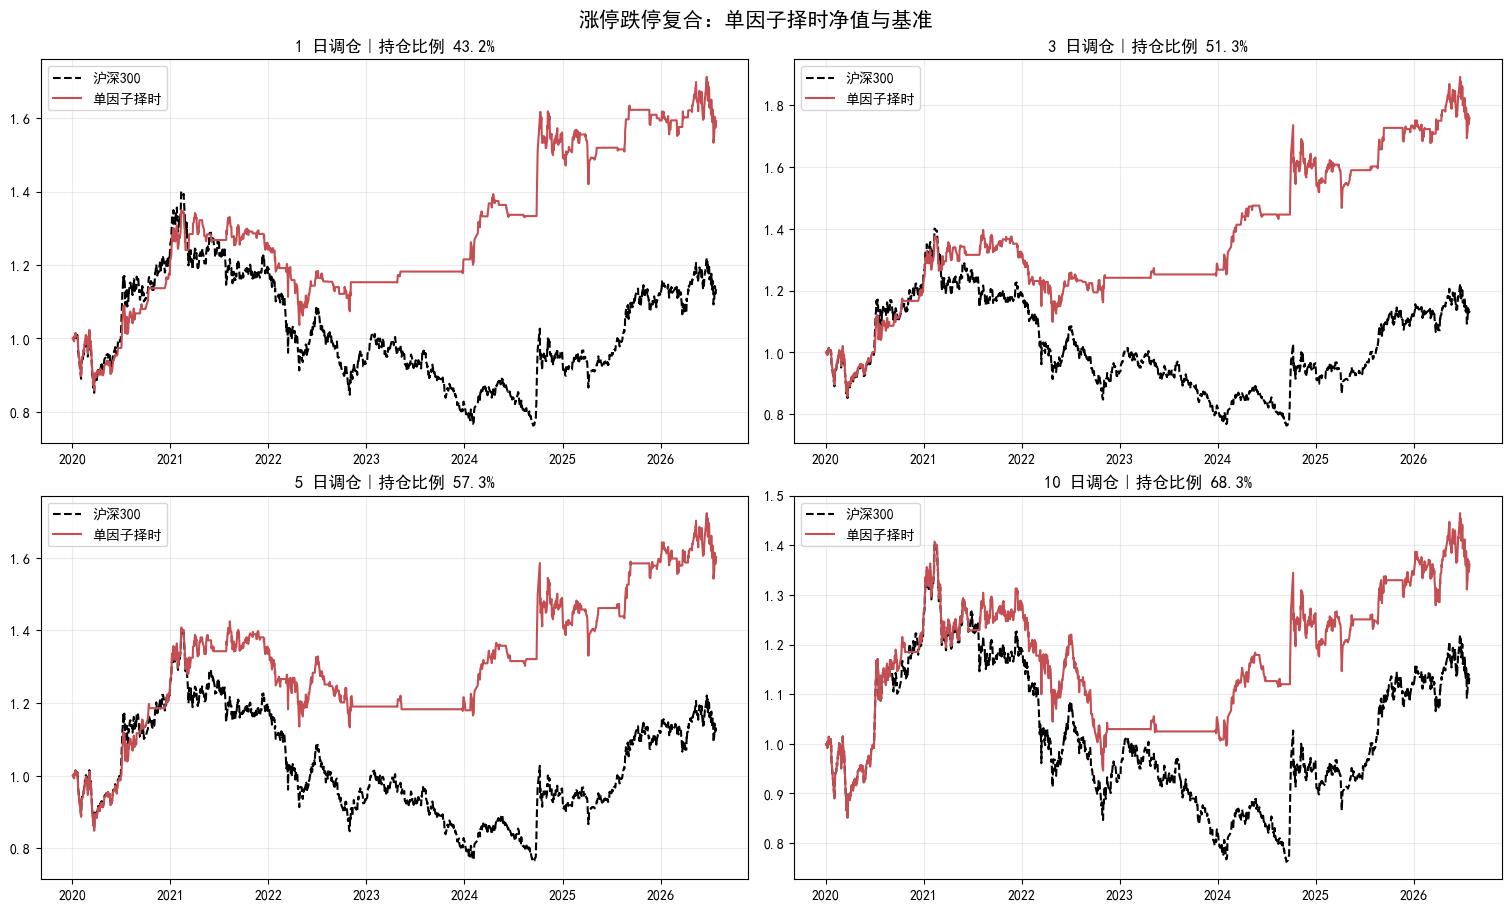

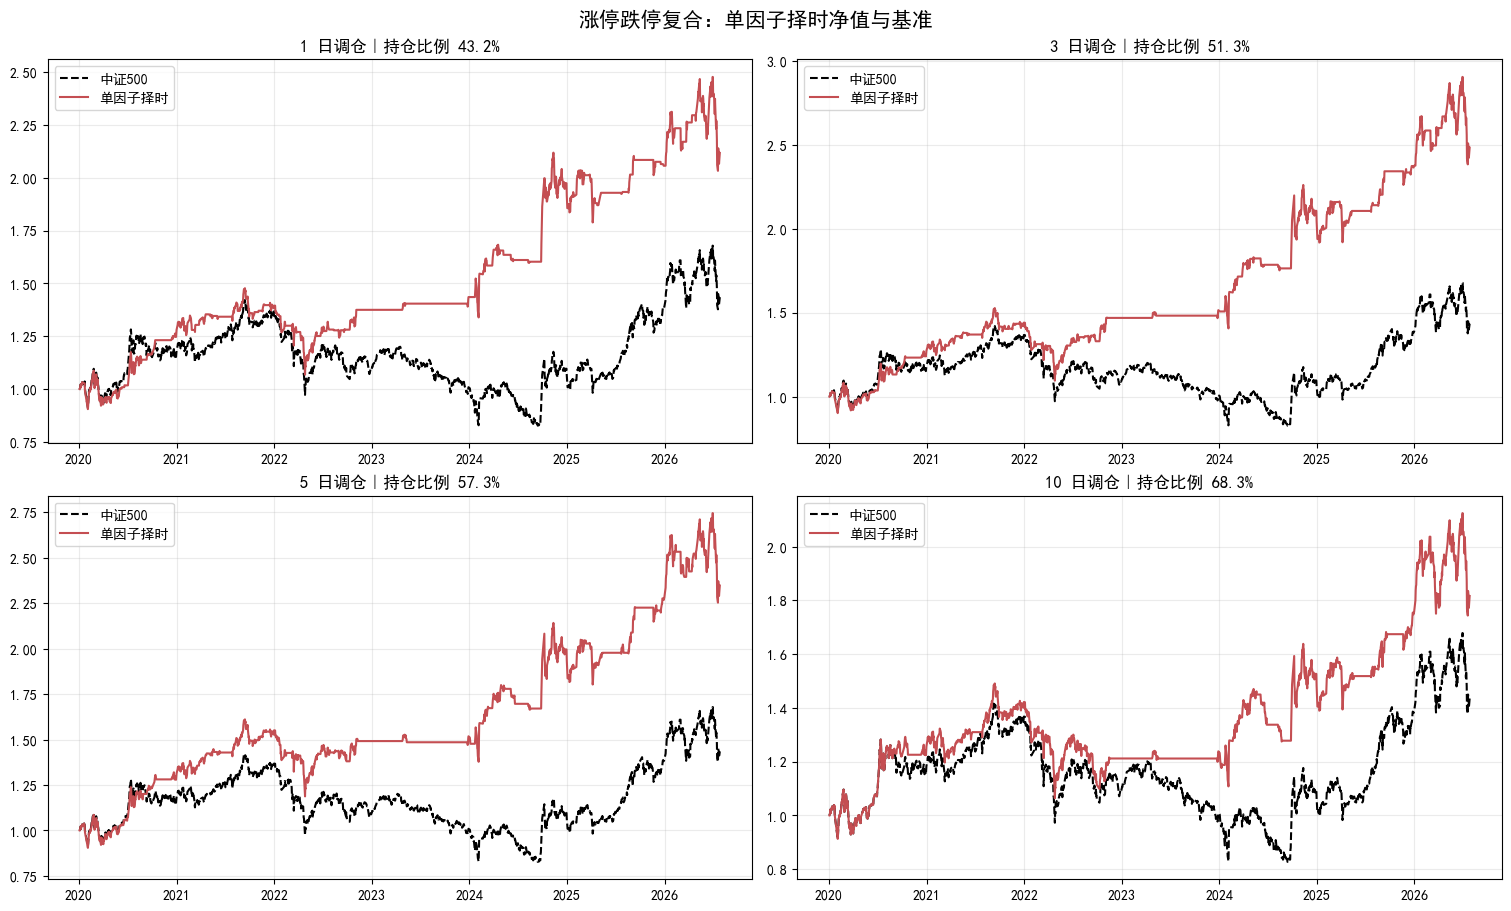

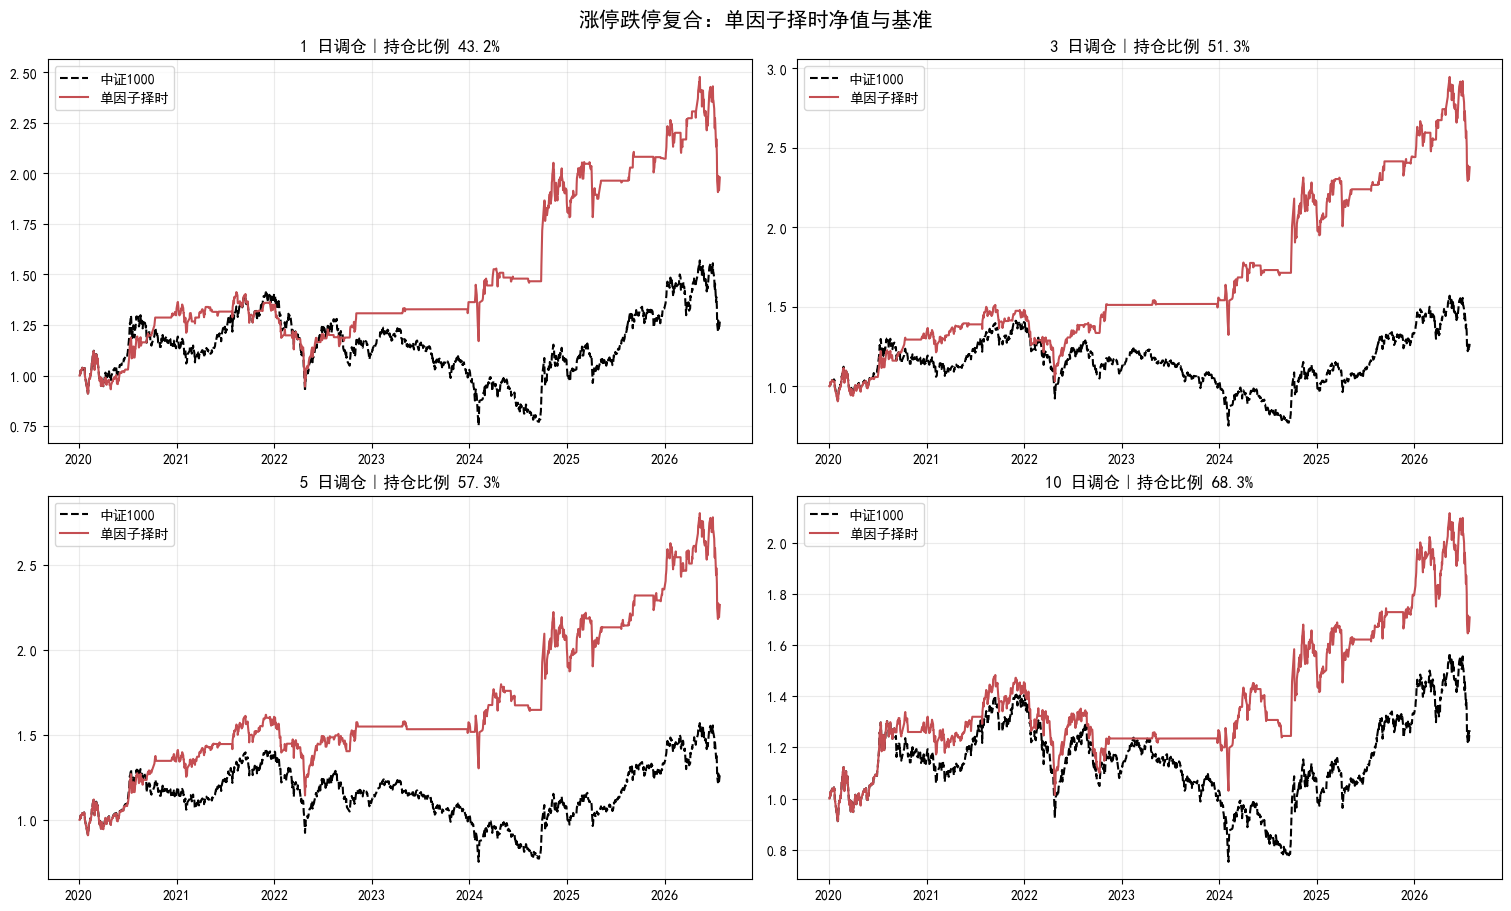

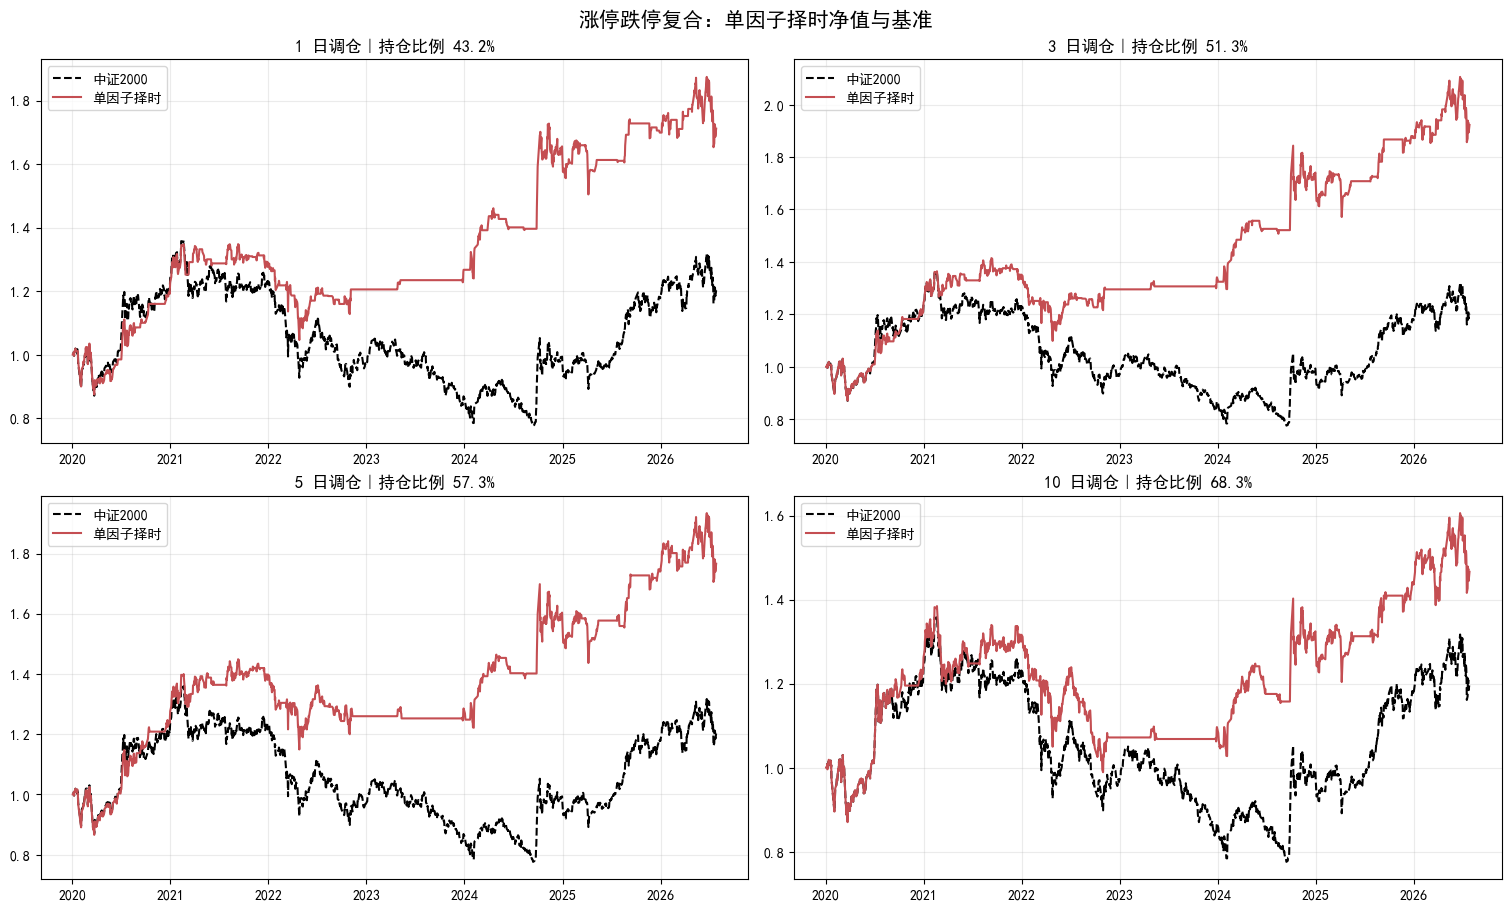

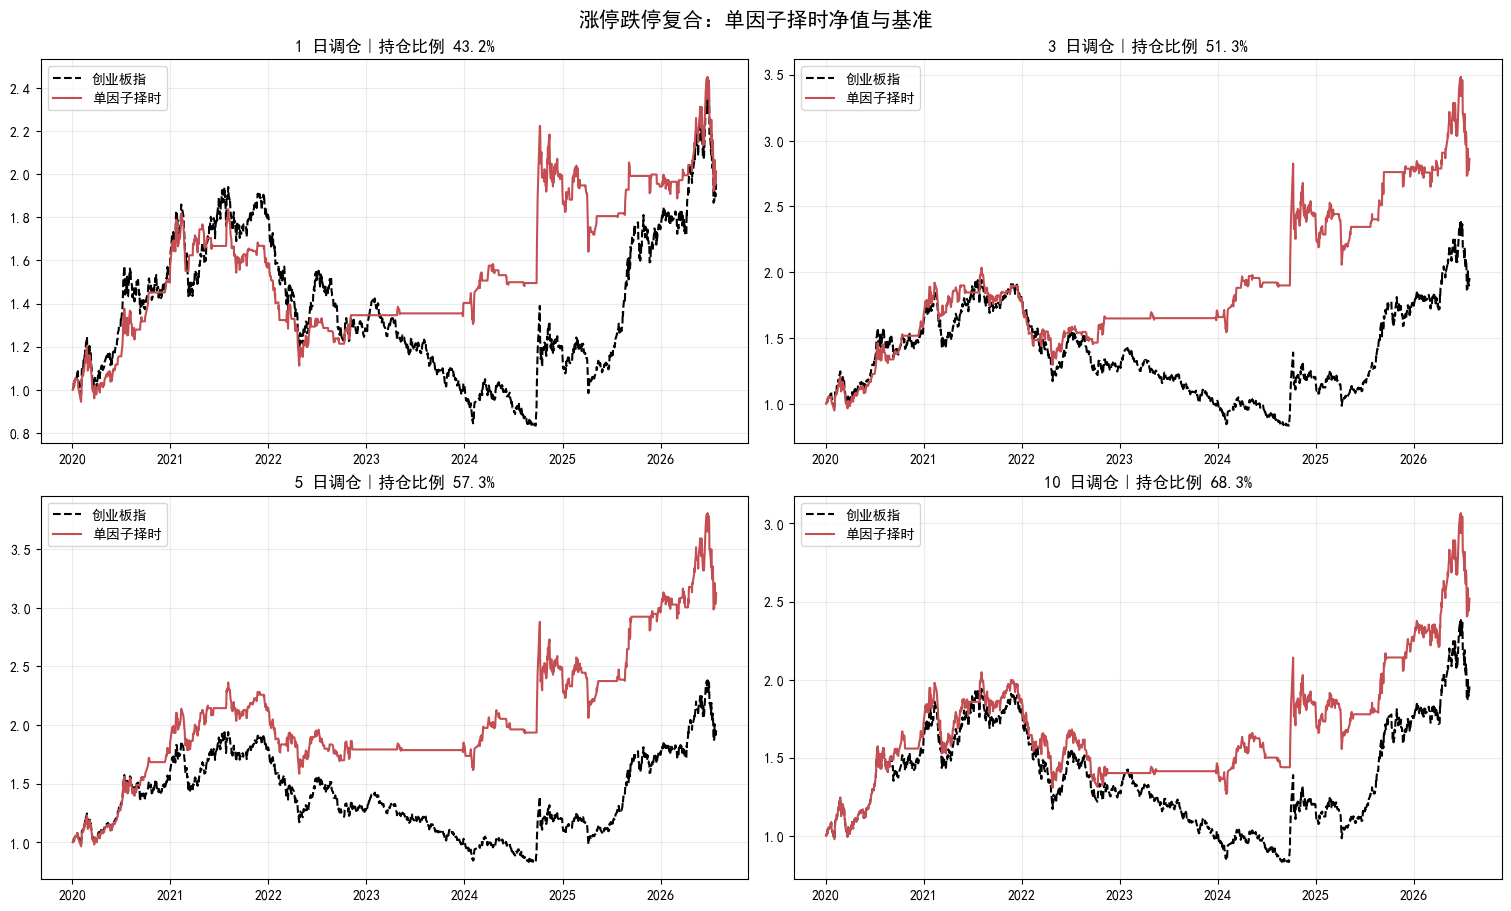

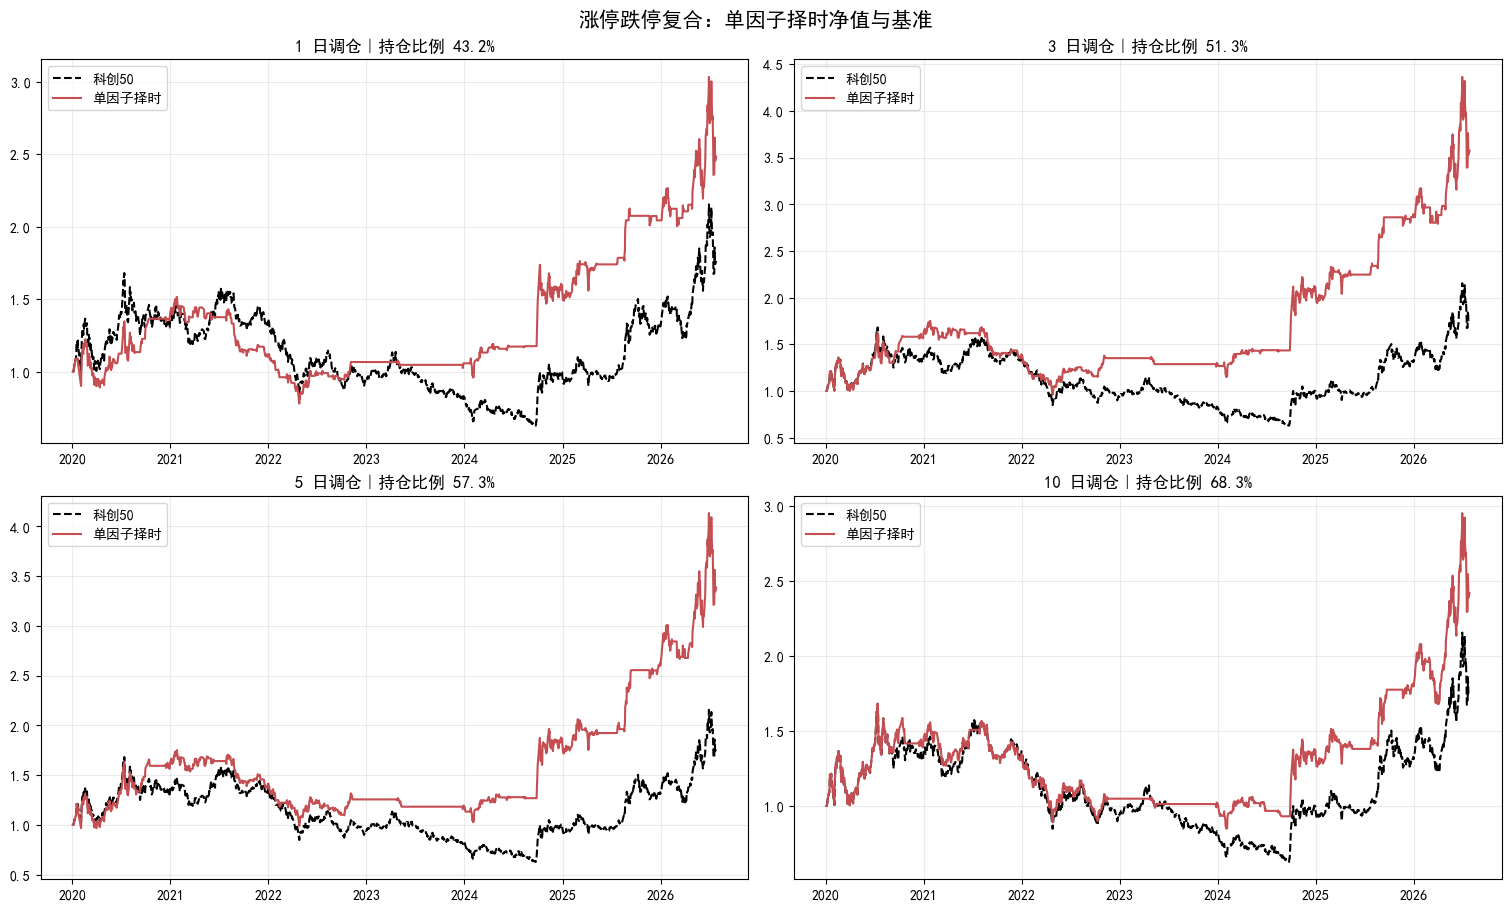

factor_label,涨停跌停复合
benchmark_label,
中证1000,7.53%
中证2000,5.95%
中证500,6.69%
创业板指,0.48%
沪深300,5.67%
科创50,6.02%


factor_label,涨停跌停复合
benchmark_label,
中证1000,10.82%
中证2000,7.97%
中证500,9.59%
创业板指,6.88%
沪深300,7.38%
科创50,12.88%


factor_label,涨停跌停复合
benchmark_label,
中证1000,9.94%
中证2000,6.49%
中证500,8.55%
创业板指,8.56%
沪深300,5.77%
科创50,11.82%


factor_label,涨停跌停复合
benchmark_label,
中证1000,4.95%
中证2000,3.30%
中证500,3.99%
创业板指,4.52%
沪深300,3.02%
科创50,5.51%


In [19]:
# ====== 因子级阈值配置：每个因子可独立设定分位数区间 ======
# {因子名: (lower_quantile, upper_quantile)}
FACTOR_THRESHOLD_CONFIG = {
    "limit_up_ratio": (0.65, 1.0),
    "limit_down_ratio": (0.65, 1.0),
    "limit_up_next_ret": (0.30, 0.85),
    "limit_down_next_ret": (0.30, 0.85),
}

# 复合信号组：组名 → 因子列表（OR 逻辑：任一因子在阈值内即触发 1）
COMPOSITE_SIGNALS = {
    "up_down_composite": ["limit_up_ratio", "limit_down_ratio"],
}
COMPOSITE_SIGNAL_LABELS = {
    "up_down_composite": "涨停跌停复合",
}

# ====== 按因子级配置分组装入阈值（每组调一次 compute_threshold）======
from collections import defaultdict
config_groups = defaultdict(list)
for factor, quantiles in FACTOR_THRESHOLD_CONFIG.items():
    config_groups[quantiles].append(factor)

timing_input = factor_data.copy()
for quantiles, factors_in_group in config_groups.items():
    temp = compute_threshold(
        factor_data, factors_in_group, THRESHOLD_QUANTILE,
        lower_quantile=quantiles[0], upper_quantile=quantiles[1],
        min_history=MIN_HISTORY,
    )
    for factor in factors_in_group:
        timing_input[f"lower_{factor}"] = temp[f"lower_{factor}"]
        timing_input[f"upper_{factor}"] = temp[f"upper_{factor}"]

# ====== 生成复合信号（OR 逻辑）======
for signal_name, factors in COMPOSITE_SIGNALS.items():
    conditions = (
        (timing_input[factors[0]] >= timing_input[f"lower_{factors[0]}"])
        & (timing_input[factors[0]] <= timing_input[f"upper_{factors[0]}"])
    )
    for factor in factors[1:]:
        conditions |= (
            (timing_input[factor] >= timing_input[f"lower_{factor}"])
            & (timing_input[factor] <= timing_input[f"upper_{factor}"])
        )
    timing_input[f"signal_{signal_name}"] = conditions.astype(float)

# 阈值使用完整因子历史计算，绩效样本再裁到五个指数的共同区间。
signals = timing_input.loc[
    timing_input["trading_date"].between(common_start, common_end)
].reset_index(drop=True)

# 检查所有因子阈值列均有效
threshold_columns = [f"lower_{factor}" for factor in FACTOR_THRESHOLD_CONFIG]
common_valid = signals[threshold_columns].notna().all(axis=1)
if not common_valid.any():
    raise ValueError("共同区间内没有完成阈值预热，请扩大历史区间或减小 MIN_HISTORY")
common_anchor = pd.Timestamp(signals.loc[common_valid.idxmax(), "trading_date"])

benchmark_data = {}
daily, blocks, timing_summary_rows = {}, {}, []
for benchmark, returns in benchmark_returns.items():
    data = signals.merge(returns, on="trading_date", how="inner", validate="one_to_one")
    if len(data) != len(signals):
        missing_count = len(signals) - len(data)
        raise ValueError(f"指数 {benchmark} 在共同区间缺少 {missing_count} 个交易日收益")
    benchmark_data[benchmark] = data

    for signal_name in COMPOSITE_SIGNALS:
        for horizon in HORIZONS:
            daily_detail, block_detail = run_time_backtest(
                data=data,
                signal_column=f"signal_{signal_name}",
                ret_column="benchmark_ret",
                horizon=horizon,
                anchor_date=common_anchor,
            )
            key = (benchmark, signal_name, horizon)
            daily[key] = daily_detail
            blocks[key] = block_detail
            summary_row = summarize_timing(
                daily_detail, block_detail, factor=signal_name, horizon=horizon,
                ret_column="benchmark_ret",
            )
            summary_row["factor_label"] = COMPOSITE_SIGNAL_LABELS.get(signal_name, signal_name)
            summary_row.update(
                benchmark=benchmark, benchmark_label=BENCHMARK_LABELS[benchmark],
            )
            timing_summary_rows.append(summary_row)

timing_summary = pd.DataFrame(timing_summary_rows)
timing_summary["annual_excess_return"] = (
    timing_summary["annual_return"] - timing_summary["benchmark_annual_return"]
)
display(timing_summary)

for benchmark in BENCHMARK_CODES:
    single_daily = {
        (signal_name, horizon): daily[(benchmark, signal_name, horizon)]
        for signal_name in COMPOSITE_SIGNALS for horizon in HORIZONS
    }
    plot_timing_nav_comparison(
        single_daily, factor_columns=list(COMPOSITE_SIGNALS), horizons=HORIZONS,
        start_date=common_anchor,
        factor_labels=COMPOSITE_SIGNAL_LABELS,
        benchmark_label=BENCHMARK_LABELS[benchmark],
    )

# 按持有期展示跨指数年化超额收益热力表
for horizon in HORIZONS:
    timing_matrix = (
        timing_summary.loc[timing_summary["horizon"] == horizon]
        .pivot(index="benchmark_label", columns="factor_label", values="annual_excess_return")
    )
    display(
        timing_matrix.style
        .background_gradient(cmap="RdYlGn", axis=None)
        .format("{:.2%}")
        .set_caption(f"{horizon} 日持有期：年化超额收益")
    )